In [1]:
import pandas as pd

In [2]:
path = "../data/df_model.csv"

df = pd.read_csv(path, low_memory=False)

df.head()

,readmitted,age,repaglinide,specialty_grouped,acarbose,pioglitazone,miglitol,glyburide-metformin,tolbutamide,rosiglitazone,chlorpropamide,glipizide,number_inpatient,diag_2g,severity,total_visits
0,0,[10-20),No,Other,No,No,No,No,No,No,No,No,0,diabetes,30,0
1,0,[20-30),No,Other,No,No,No,No,No,No,No,Steady,1,diabetes,14,3
2,0,[30-40),No,Other,No,No,No,No,No,No,No,No,0,diabetes,16,0
3,0,[40-50),No,Other,No,No,No,No,No,No,No,Steady,0,neoplasms,6,0
4,0,[50-60),No,Other,No,No,No,No,No,No,No,No,0,circulatory,30,0


## Splitting Data

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop("readmitted", axis=1)
y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=631, stratify=y)

## Transforming

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler

from sklearn.feature_selection import SelectFromModel
from sklearn.svm import LinearSVC
from sklearn.feature_selection import VarianceThreshold

In [5]:
num_attribs = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_attribs = X.select_dtypes(include='object').columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs)
])

full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
])

# with svm selector
svm_selector = SelectFromModel(
    LinearSVC(C=0.01, random_state=631, max_iter=10000),
    threshold="median"
)

full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", svm_selector),
])

In [6]:
X_train_prepared = full_pipeline.fit_transform(X_train, y_train)
X_test_prepared = full_pipeline.transform(X_test)

# undersampling for model comparison / feature selection
rus = RandomUnderSampler(replacement=False)
X_train_prepared, y_train = rus.fit_resample(X_train_prepared, y_train)

# variance threshold
# selector = VarianceThreshold(threshold=0.01)

# X_train_selected = selector.fit_transform(X_train_prepared)
# X_test_selected = selector.transform(X_test_prepared)

### Baseline model for feature selection

In [7]:
from sklearn.linear_model import LogisticRegression
import numpy as np

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train_prepared, y_train)

feature_names = full_pipeline.get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(model.coef_[0])
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)
print("\nImportant Features:\n")
print(importance.head(20))


Important Features:

                          Feature  Importance
2                cat__age_[10-20)    0.920174
7   cat__specialty_grouped_OB/GYN    0.840101
6             cat__repaglinide_Up    0.630446
1                 cat__age_[0-10)    0.506519
13           cat__pioglitazone_Up    0.430044
0           num__number_inpatient    0.413008
12       cat__pioglitazone_Steady    0.381075
30         cat__diag_2g_neoplasms    0.341154
23         cat__chlorpropamide_No    0.306982
9            cat__acarbose_Steady    0.305616
24     cat__chlorpropamide_Steady    0.285571
25              cat__glipizide_No    0.281019
4             cat__repaglinide_No    0.279819
21        cat__rosiglitazone_Down    0.265913
11           cat__pioglitazone_No    0.247469
22          cat__rosiglitazone_Up    0.226121
19            cat__tolbutamide_No    0.224614
26          cat__glipizide_Steady    0.220169
20        cat__tolbutamide_Steady    0.203203
27              cat__glipizide_Up    0.186511


In [8]:
importance_list = importance['Feature']
importance_list.to_list()

['cat__age_[10-20)',
 'cat__specialty_grouped_OB/GYN',
 'cat__repaglinide_Up',
 'cat__age_[0-10)',
 'cat__pioglitazone_Up',
 'num__number_inpatient',
 'cat__pioglitazone_Steady',
 'cat__diag_2g_neoplasms',
 'cat__chlorpropamide_No',
 'cat__acarbose_Steady',
 'cat__chlorpropamide_Steady',
 'cat__glipizide_No',
 'cat__repaglinide_No',
 'cat__rosiglitazone_Down',
 'cat__pioglitazone_No',
 'cat__rosiglitazone_Up',
 'cat__tolbutamide_No',
 'cat__glipizide_Steady',
 'cat__tolbutamide_Steady',
 'cat__glipizide_Up',
 'cat__repaglinide_Down',
 'cat__repaglinide_Steady',
 'cat__acarbose_No',
 'cat__glyburide-metformin_Down',
 'cat__diag_2g_respiratory',
 'cat__glyburide-metformin_No',
 'cat__acarbose_Up',
 'cat__miglitol_No',
 'cat__glyburide-metformin_Steady',
 'cat__diag_2g_musculoskeletal',
 'cat__miglitol_Steady',
 'cat__diag_2g_digestive']

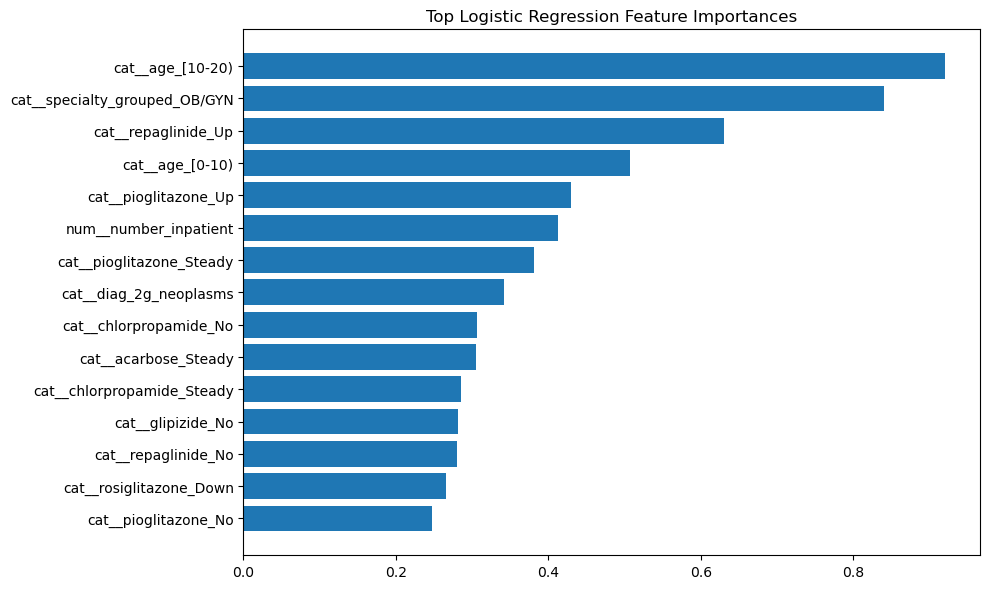

In [9]:
import matplotlib.pyplot as plt

top_features = importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.gca().invert_yaxis()

plt.title("Top Logistic Regression Feature Importances")
plt.tight_layout()
plt.show()

## Models

In [10]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score, RocCurveDisplay

In [11]:
def model_results(y_test, y_pred, name):
    print(f"=={name}==\n")

    RocCurveDisplay.from_predictions(
        y_test,
        y_pred
    )
    
    plt.title("ROC Curve")
    plt.show()
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nPrecision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("\nF1 Score:", f1_score(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

==GaussianNB==



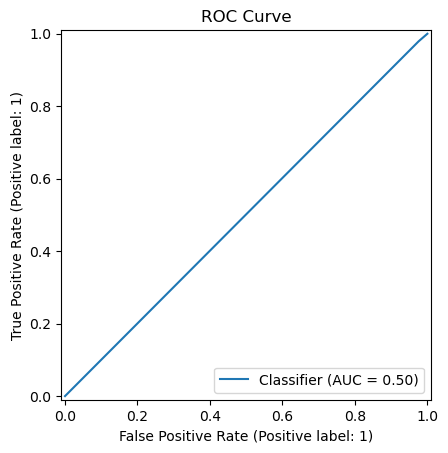

Accuracy: 0.1313282457977954

Precision: 0.11255875740854282
Recall: 0.9791111111111112

F1 Score: 0.20190633305838146

Confusion Matrix:
 [[  430 17369]
 [   47  2203]]


In [12]:
model = GaussianNB()

# # have to convert to array for gaussian
X_train_dense = X_train_prepared.toarray()
X_test_dense = X_test_prepared.toarray()

model.fit(X_train_dense, y_train)

y_pred = model.predict(X_test_dense)

model_results(y_test, y_pred, "GaussianNB")

==Random Forest Classifier==



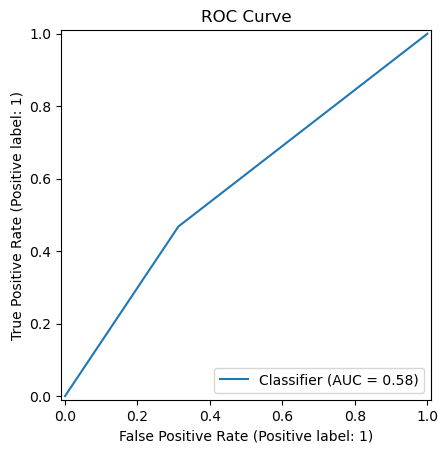

Accuracy: 0.6625268093171729

Precision: 0.15901540320144972
Recall: 0.468

F1 Score: 0.23737601442741207

Confusion Matrix:
 [[12230  5569]
 [ 1197  1053]]


In [13]:
model = RandomForestClassifier(n_estimators=100, random_state=631)

model.fit(X_train_prepared, y_train)

y_pred = model.predict(X_test_prepared)

model_results(y_test, y_pred, "Random Forest Classifier")

==K-Nearest Neighbors==



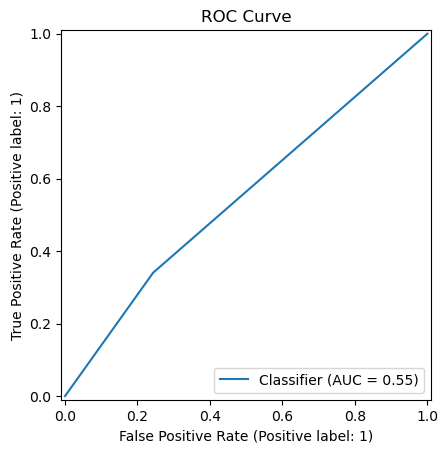

Accuracy: 0.7101601077360467

Precision: 0.15040251325348516
Recall: 0.34044444444444444

F1 Score: 0.20863407326705707

Confusion Matrix:
 [[13472  4327]
 [ 1484   766]]


In [14]:
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train_prepared, y_train)

y_pred = model.predict(X_test_prepared)

model_results(y_test, y_pred, "K-Nearest Neighbors")